In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from dpsbp_operators_correct import *
from RK4 import * 
from SWESBP import * 
from scipy.optimize import fsolve

In [2]:
import timeit

#plt.switch_backend("TkAgg")          # plots in external window
plt.switch_backend("nbagg") 
from matplotlib import rcParams

# latex
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{bm}'
# basics
rcParams['lines.linewidth'] = 1.2
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 17
rcParams['axes.linewidth'] = 0.8
# x-ticks
rcParams['xtick.top'] = True
rcParams['xtick.direction'] = 'in'
rcParams['xtick.minor.visible'] = True
rcParams['xtick.major.size'] = 6
rcParams['xtick.minor.size'] = 3
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.width'] = 1.5
rcParams['xtick.major.pad'] = 5
rcParams['xtick.minor.pad'] = 5
# y-ticks
rcParams['ytick.right'] = True
rcParams['ytick.direction'] = 'in'
rcParams['ytick.minor.visible'] = True
rcParams['ytick.major.size'] = 6
rcParams['ytick.minor.size'] = 3
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.width'] = 1.5
rcParams['ytick.major.pad'] = 5
rcParams['ytick.minor.pad'] = 5
# legend
rcParams['legend.fontsize'] = 15 #rcParams['font.size']
rcParams['legend.labelspacing'] = 0.2
rcParams['legend.loc'] = 'upper left'
rcParams['legend.frameon'] = False
# figure
rcParams['figure.figsize'] = (8.0, 5.0)
rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 200
rcParams['savefig.bbox'] = 'tight'


In [3]:
p1 = acoustic_sbp()
p1.mms

<bound method acoustic_sbp.mms of <SWESBP.acoustic_sbp object at 0x11ad56fe0>>

In [4]:
def compute_cm(vars1):
    hl = 1.0
    hr = 0.5
    cm = vars1
    #hl = 1 
    #hr = 1
    
    g = 9.81 
    
    eqn1 = -8*g * hr * cm**2 * ( np.sqrt(g * hl) - cm)**2 + (cm**2 -g*hr)**2 * (cm**2 + g*hr)
    
    
    return eqn1

cm_val = fsolve(compute_cm, [2])
print(cm_val)
2.67041**2/9.81

[2.67041]


0.7269204452701324

In [5]:
#see SWASHES 2013 paper (note there is a mistake in their paper, so look at arXiv version)
def analytical_Dam_Break(y, t):
    hl = 1.0
    hr = 0.5
    g = 9.81
    x0 = 5
    cm_val = fsolve(compute_cm, [2])
    #print(cm_val[0])
    #values = np.array([fsolve(compute_cm, [3])])
    #print(values)# Compute cm for each value in y
    cm = cm_val[0]
    #print(cm)
    
    h = np.zeros_like(y)  # Initialize h with zeros
    
    mask1 = y <= (x0 - t * np.sqrt(g * hl))  # Mask for the first condition
    mask2 = np.logical_and((x0 - t * np.sqrt(g * hl)) <= y, y <= (x0 + t * (2 * np.sqrt(g * hl) - 3 * cm)))
  # Mask for the second condition
    mask3 = np.logical_and((x0 + t * (2 * np.sqrt(g * hl) - 3 * cm)) <= y, y <= (x0 + t * (2 * cm**2) * (np.sqrt(g * hl) - cm) / (cm**2 - g * hr)))  # Mask for the third condition
    mask4 = (x0 + t * ((2 * cm**2) * (np.sqrt(g * hl) - cm)) / (cm**2 - g * hr)) <= y  # Mask for the fourth condition
    
    h[mask1] = hl
    h[mask2] = (4 / (9 * g)) * (np.sqrt(g*hl) - (y[mask2]-x0) / (2 * t))**2
    h[mask3] = cm**2 / g
    h[mask4] = hr
    
    return h
                                            
    
 

#cm = fsolve(compute_cm,[1,1,2])

In [6]:
#see SWASHES 2013 paper (note there is a mistake in their paper)
def analytical_Dam_Break_vel(y, t):
    hl = 1.0
    hr = 0.5
    g = 9.81
    x0 = 5
    cm_val = fsolve(compute_cm, [2])
    #print(cm_val[0])
    #values = np.array([fsolve(compute_cm, [3])])
    #print(values)# Compute cm for each value in y
    cm = cm_val[0]
    #print(cm)
    
    V = np.zeros_like(y)  # Initialize h with zeros
    
    mask1 = y <= (x0 - t * np.sqrt(g * hl))  # Mask for the first condition
    mask2 = np.logical_and((x0 - t * np.sqrt(g * hl)) <= y, y <= (x0 + t * (2 * np.sqrt(g * hl) - 3 * cm)))
  # Mask for the second condition
    mask3 = np.logical_and((x0 + t * (2 * np.sqrt(g * hl) - 3 * cm)) <= y, y <= (x0 + t * (2 * cm**2) * (np.sqrt(g * hl) - cm) / (cm**2 - g * hr)))  # Mask for the third condition
    mask4 = (x0 + t * ((2 * cm**2) * (np.sqrt(g * hl) - cm)) / (cm**2 - g * hr)) <= y  # Mask for the fourth condition
    
    V[mask1] = 0
    V[mask2] = (2/3) * ((y[mask2] - x0)/t + np.sqrt(g*hl))
    V[mask3] = 2* (np.sqrt(g*hl) - cm)
    V[mask4] = 0
    
    return V

In [7]:
# Initializations
L = 10.0         # length of the domain (km)
t = 0.0          # initial time
tend = 0.5    # final time
nx =  1001 #641#1281#2561 #3201#1601#3201      # grid points in x                                                                                                                       
dx = L/(nx-1)    # grid increment in x
    # velocity (km/s) (can be an array)                                                                                                             
iplot =300 # snapshot frequency
rho = 1#2.6702     # density [g/cm^3]
K =  2.2 #rho*cs**2 

g = 9.81
H = 10

Ubar=  -0.3*np.sqrt(g*H)# -0.3*np.sqrt(g*H)
#cs = np.sqrt(K/rho)# shear modulus [GPa]
#Zs = rho * cs
  # shear impedance 

order = 6# order of accuracy


#Initialize the domain
y = np.zeros((nx, 1))

# Initial particle velocity perturbation and discretize the domain
for j in range(0, nx):
    y[j, :] = j*dx                                             # discrete domain



# Time stepping parameters
cfl = 0.3               # CFL number
dt = (cfl/(np.abs(Ubar) + np.sqrt(g*H)))*dx                  # Time step
nt = int(round(tend/dt))          # number of time steps
n = 0                             # counter
print(nt)
# Boundary condition reflection coefficients 
r0 = 0                          # r=0:absorbing, r=1:free-surface, r=-1: clamped 
r1 = 0                            # r=0:absorbing, r=1:free-surface, r=-1: clamped

# penalty parameters
tau_11 = 1 #-1
tau_12 = 1.
tau_21 =  1 
tau_22 =  1

# Initialize: particle velocity (v); and shear stress (s)
v = np.zeros((nx, 1))
p = np.zeros((nx, 1))

U = np.zeros((nx, 1))
V = np.zeros((nx, 1))
U_t = np.zeros((nx, 1))
V_t = np.zeros((nx, 1))
U_x = np.zeros((nx, 1))
V_x = np.zeros((nx, 1))

energy = np.zeros((nx,1))
analytical_energy = np.zeros((nx,1))
                                

# Difference between analyticla and numerical solutions
EV = [0]                                 # initialize errors in V (velocity)
EU = [0]                                 # initialize errors in U (stress)
T = [0]                                  # later append every time steps to this

2146


/var/folders/y8/yypvc6yd355fxc2039gq0h2c0000gn/T/ipykernel_83451/3898461134.py:15: RuntimeWarning: overflow encountered in exp
  y = 1 / (1 + np.exp(-c * (x - a))) - 1 / (1 + np.exp(-c * (x - b)))


<IPython.core.display.Javascript object>


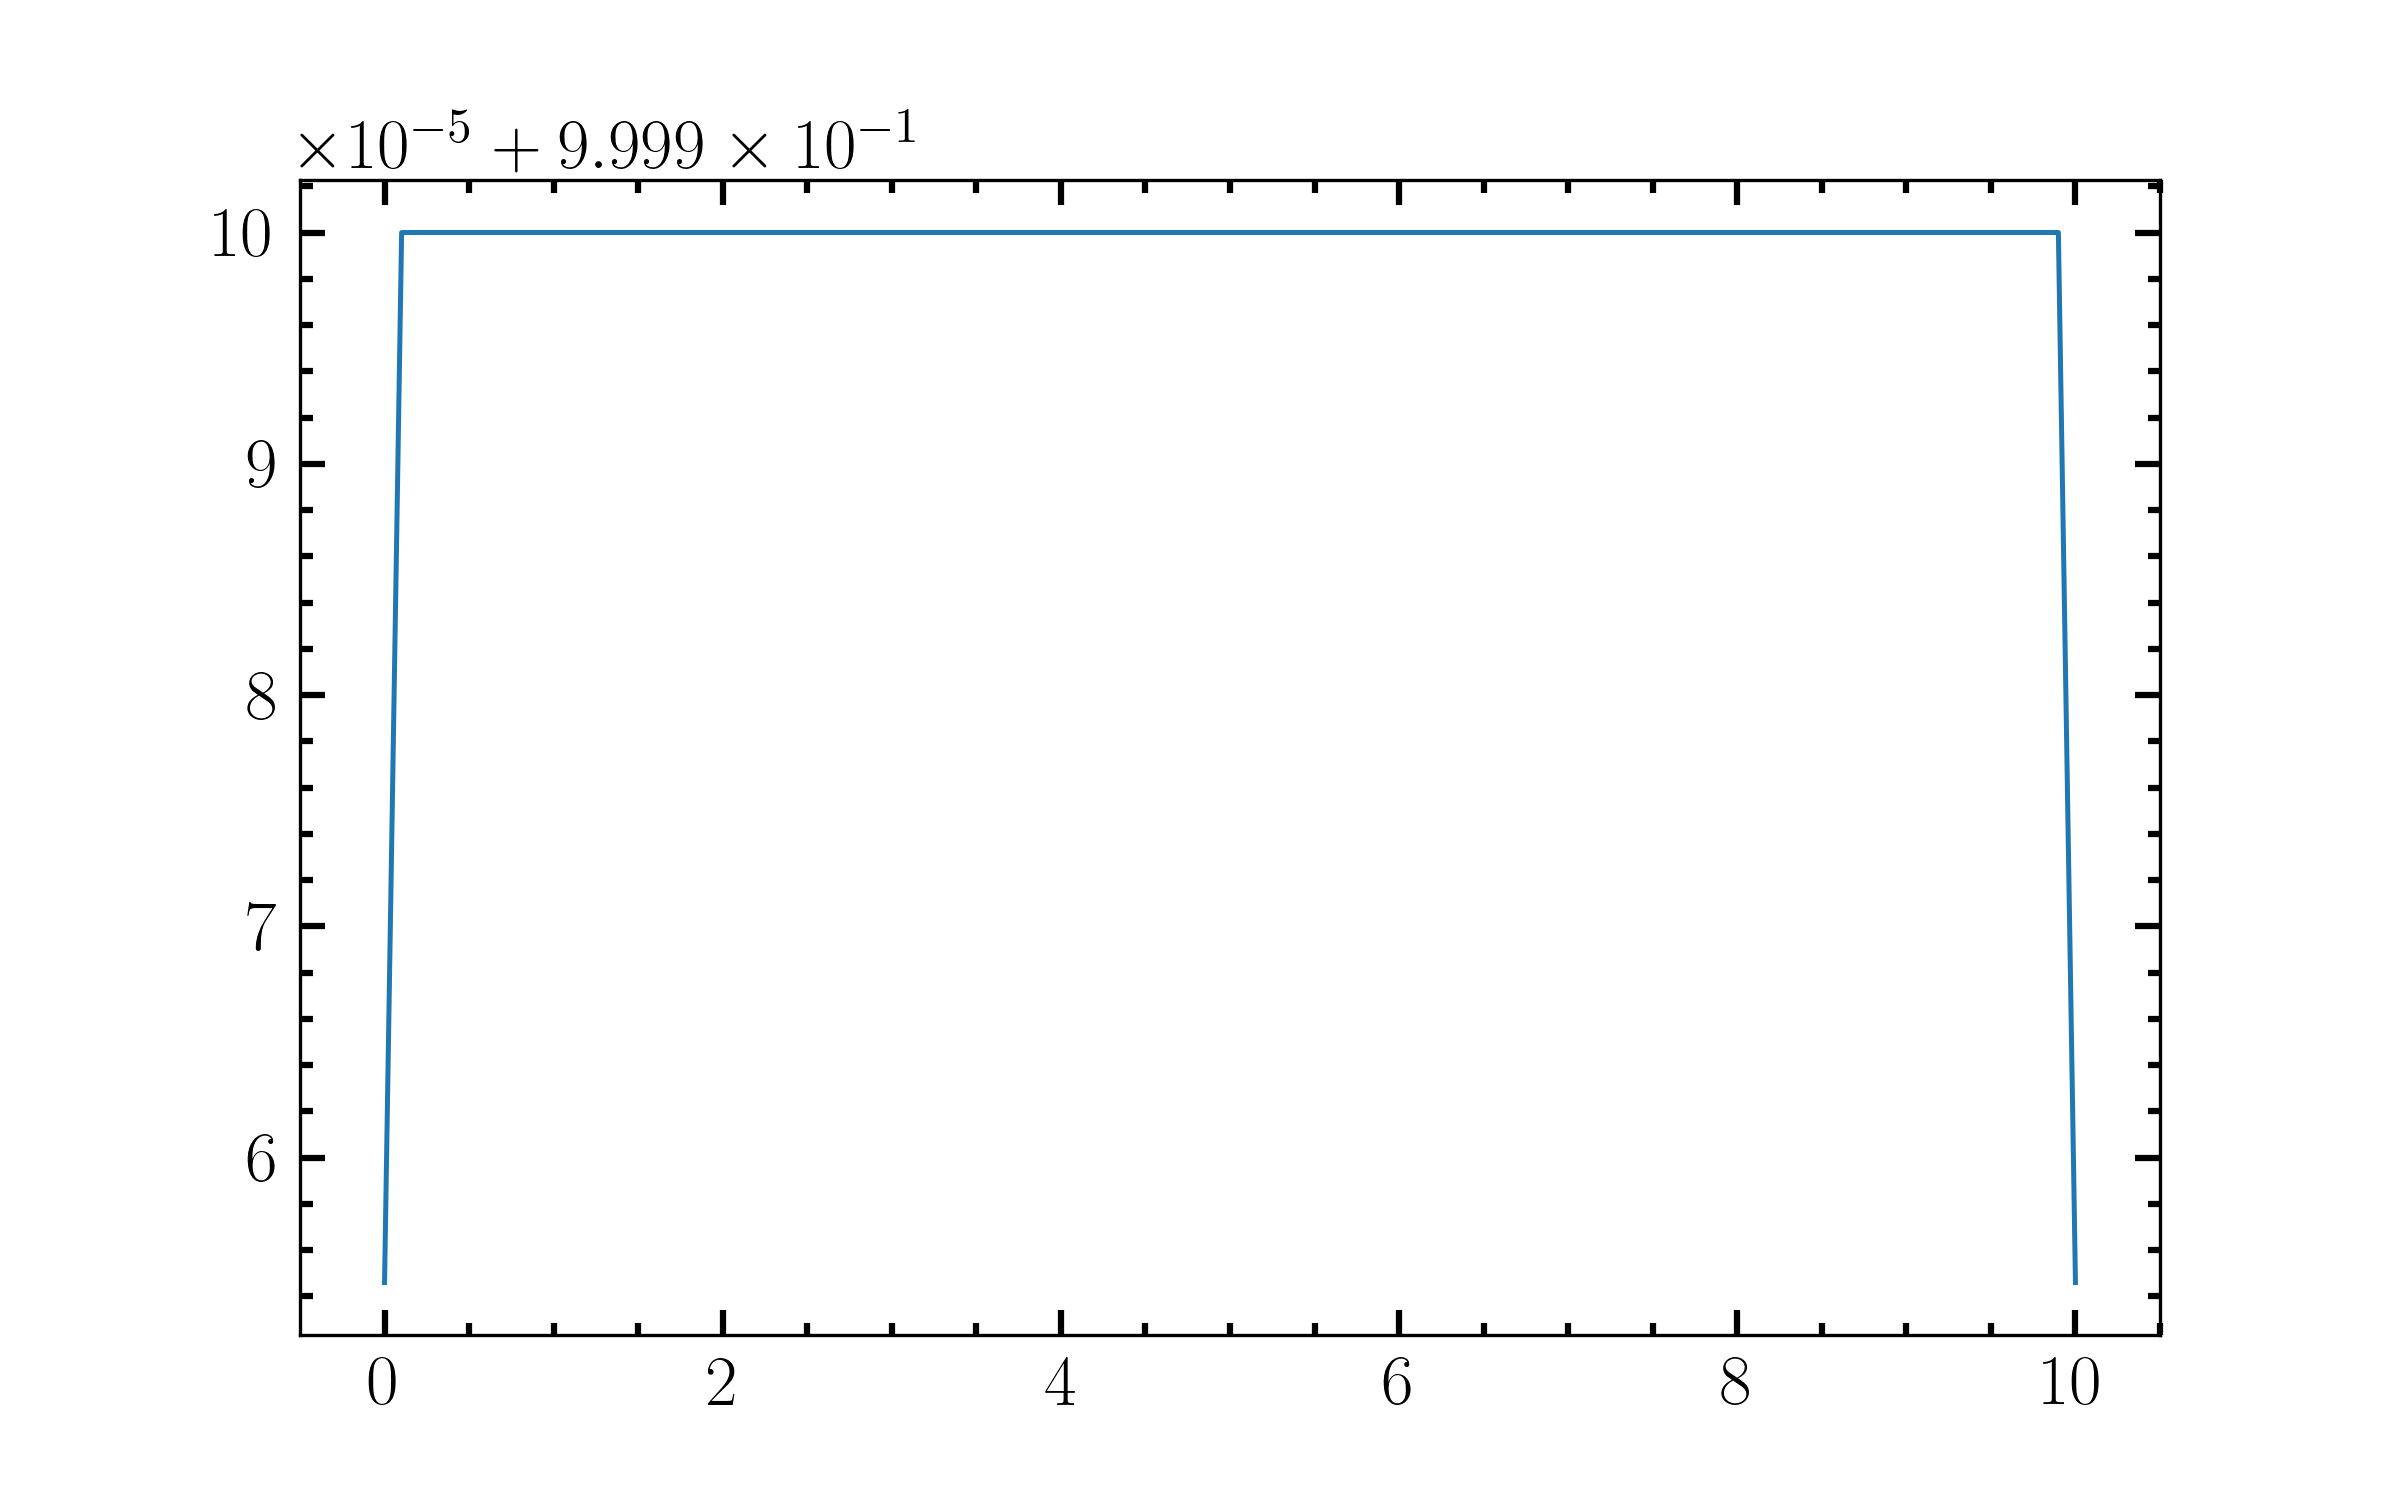

In [8]:
def smooth_boxcar(x, a, b, c):
    """
    Smooth boxcar function with zero derivative at the boundaries.

    Arguments:
    x -- input values
    a -- start of the boxcar region
    b -- end of the boxcar region
    c -- smoothness parameter

    Returns:
    y -- smoothed boxcar function values
    """

    y = 1 / (1 + np.exp(-c * (x - a))) - 1 / (1 + np.exp(-c * (x - b)))

    return y

x = np.linspace(0,10,100)


tophat = smooth_boxcar(x,-0.01*L,1.01*L,100)

plt.plot(x,tophat)
plt.show()

<IPython.core.display.Javascript object>


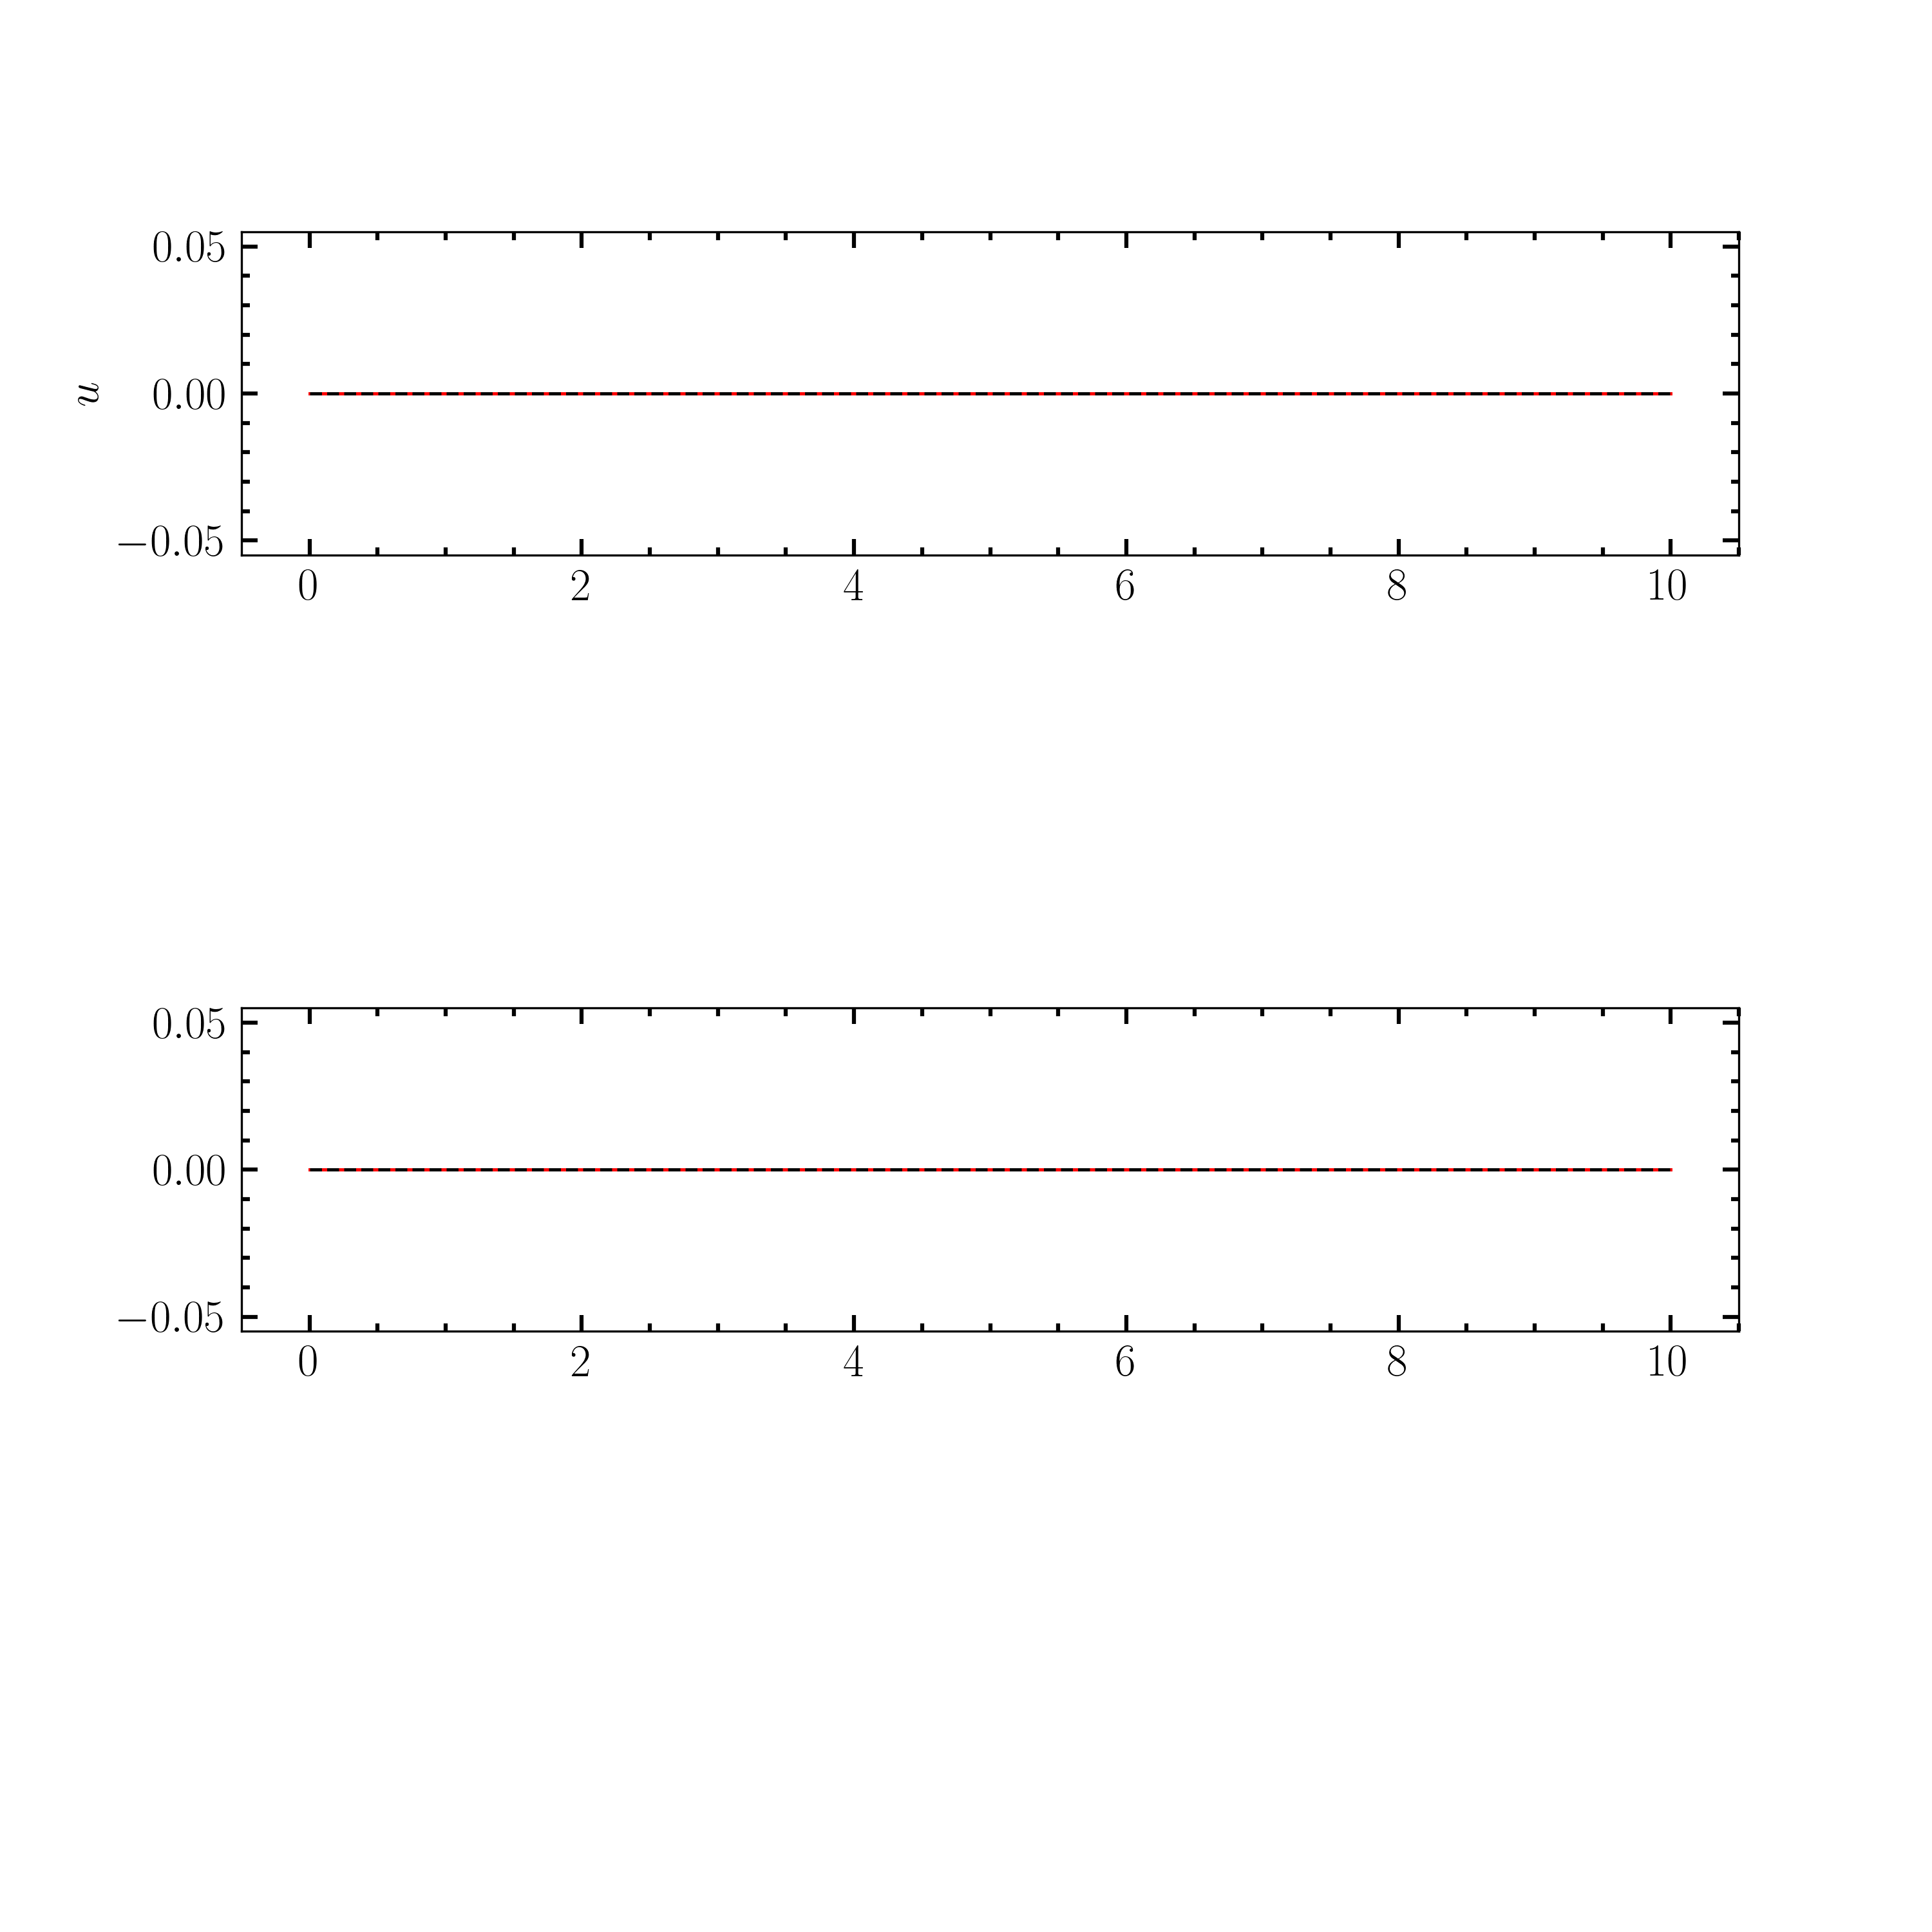

<IPython.core.display.Javascript object>


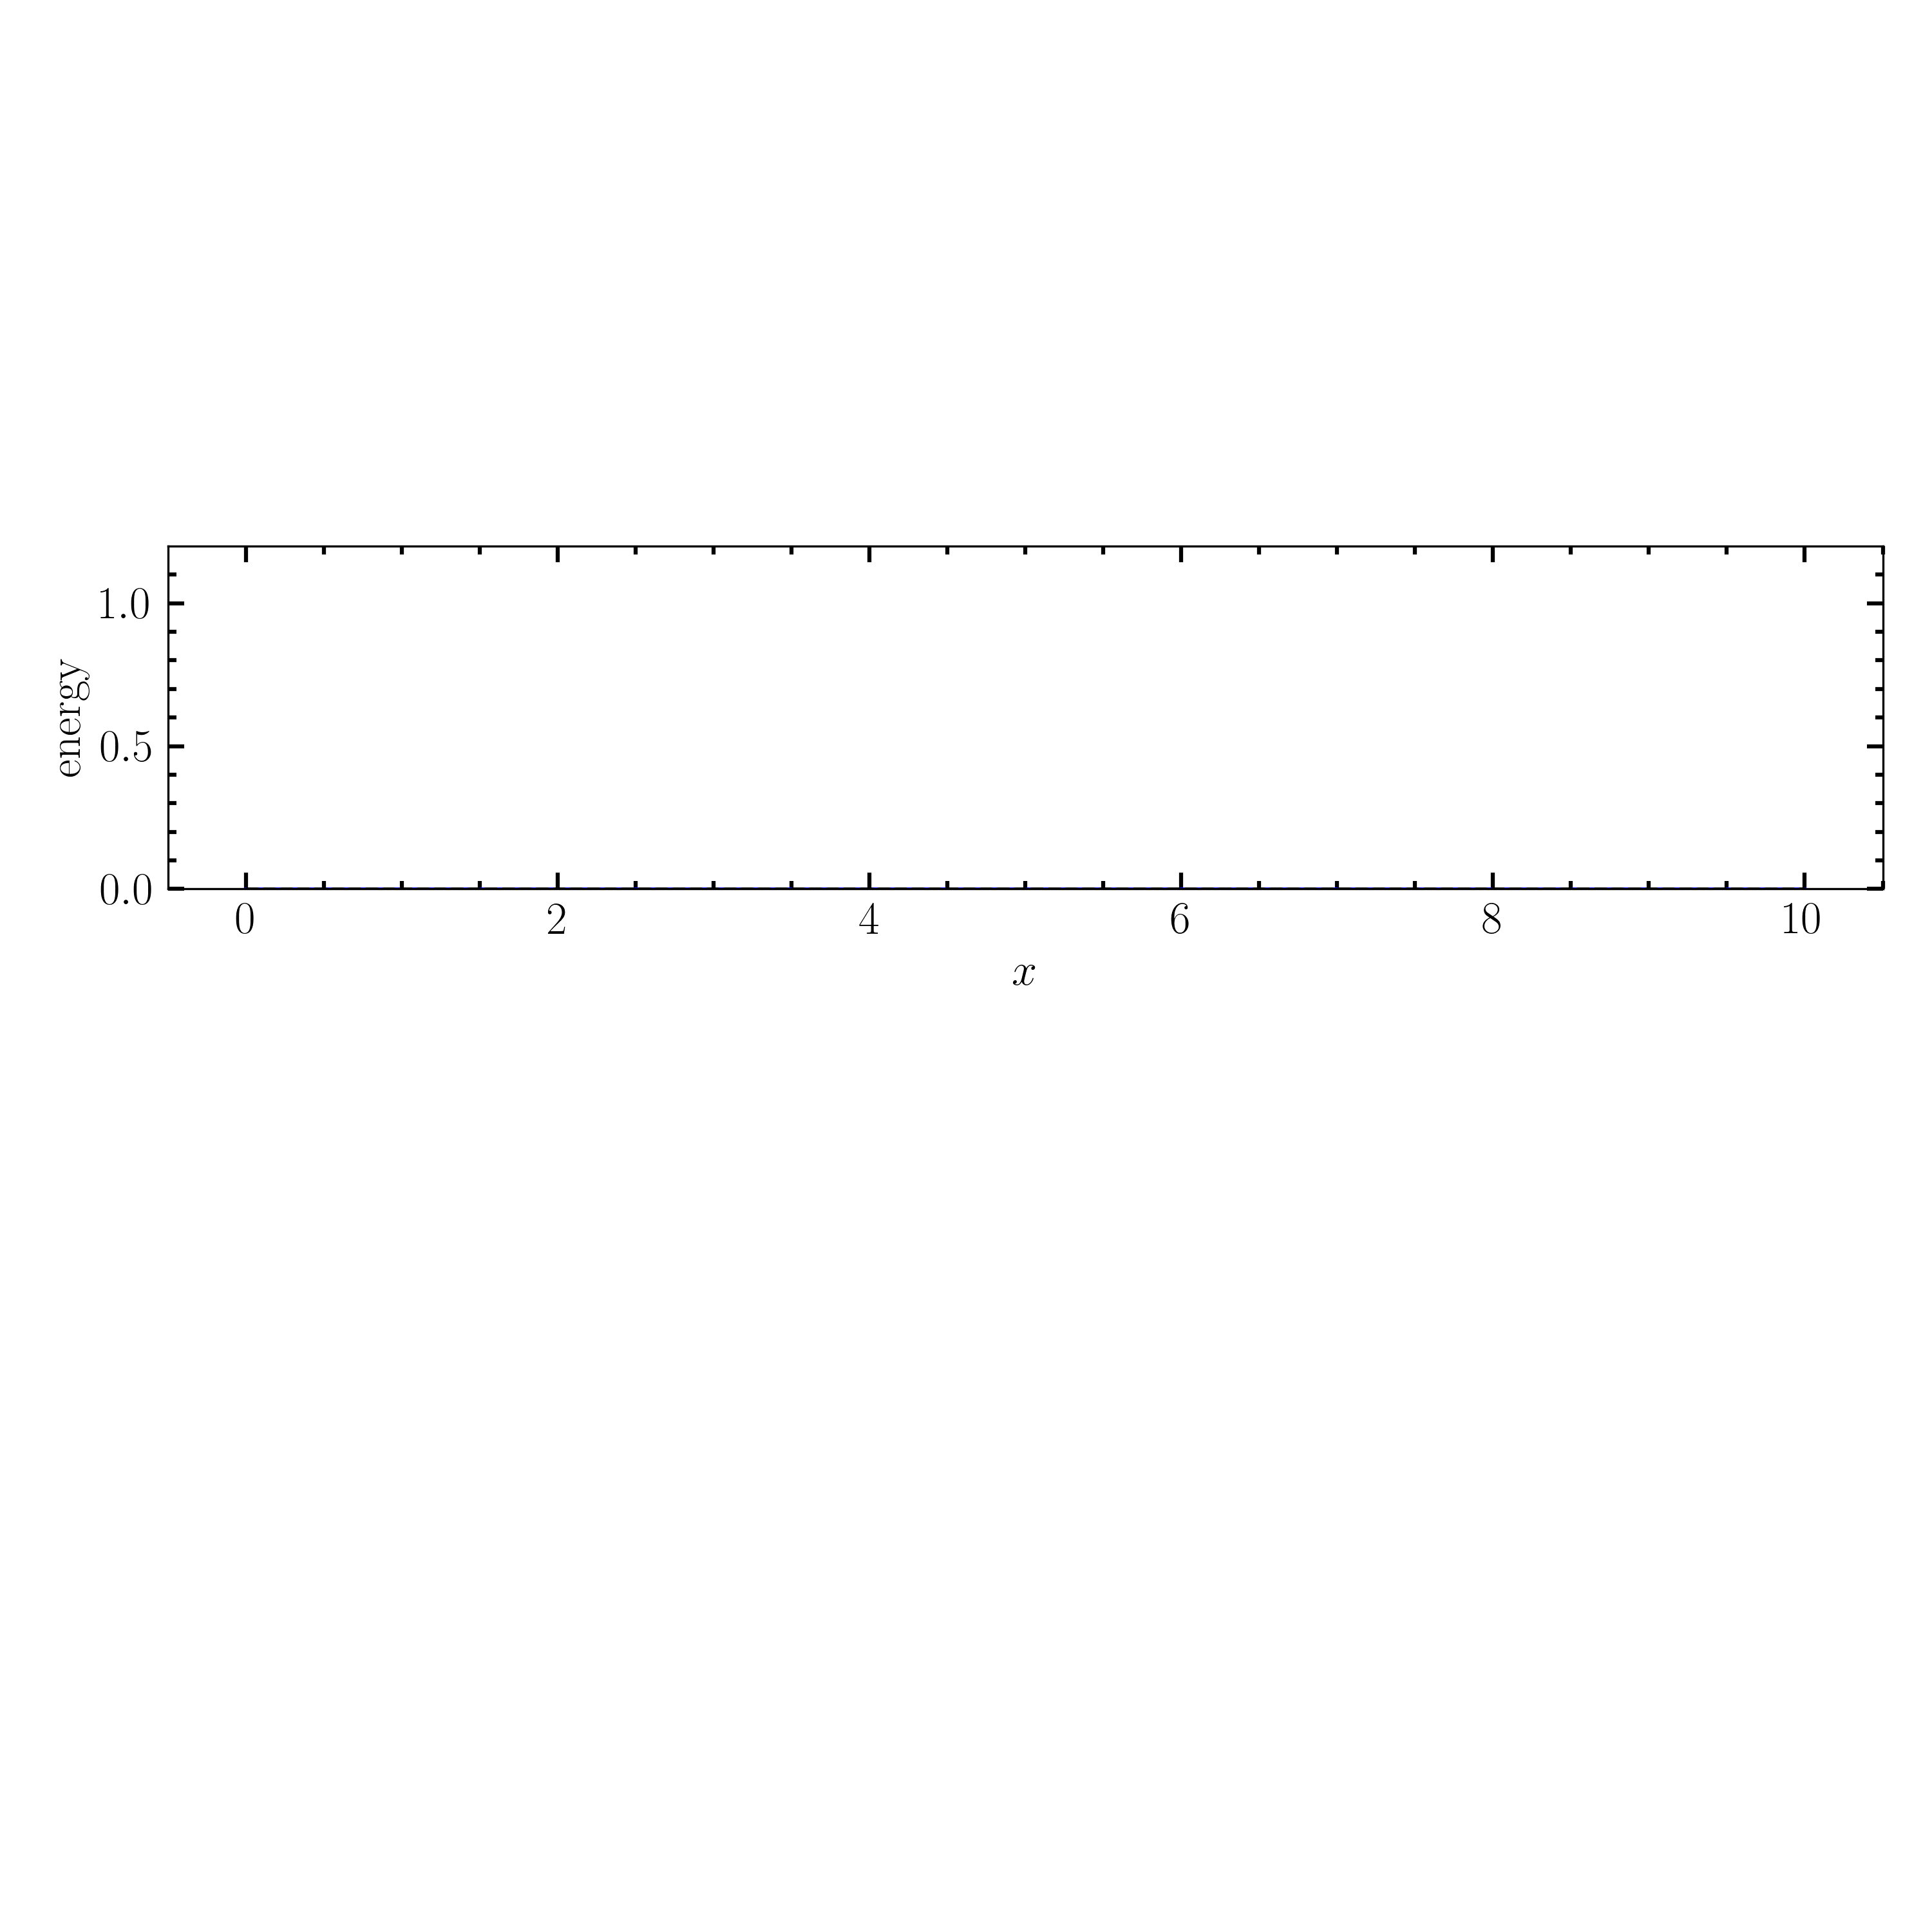

/var/folders/y8/yypvc6yd355fxc2039gq0h2c0000gn/T/ipykernel_83451/3677550955.py:88: RuntimeWarning: divide by zero encountered in double_scalars
  EU.append(np.linalg.norm(U-v)/A)


KeyboardInterrupt: 

In [9]:
# Computation and plotting

#V_alt=  np.cos(2* np.pi *t) * np.cos(5 * np.pi *y/delta + 5)#np.cos(ntv * t)*np.sin(nyv *y + fs)

#P_alt= np.sin(3*np.pi *t) * np.sin(10 * np.pi *y / delta  + 5)
# Initialize animated plot for velocity and stress
fig1 = plt.figure(figsize=(10,10))
ax1 = fig1.add_subplot(4,1,1)
line1 = ax1.plot(y, v, 'r', y, U, 'k--')
#plt.title('numerical vs exact')
#plt.xlabel(r'$x$')
plt.ylabel(r'$u$')



#ig2 = plt.figure(figsize=(10,10))
ax2 = fig1.add_subplot(4,1,2)
line2 = ax2.plot(y, p, 'b', y, V, 'k--')
#plt.title('numerical vs exact')
plt.xlabel(r'$x$')
plt.ylabel(r'$h$')
ax2.set_ylim([0.0, 1.2])

# # Initialize error plot (for velocity and stress)
ax3 = fig1.add_subplot(4,1,3)
line3 = ax3.plot(y, energy, 'r',y,analytical_energy,'k--' )
#plt.title('relative error in particle velocity')
plt.xlabel(r'$x$')
# ax3.set_ylim([10**-5, 1])
plt.ylabel('energy')


# ax4 = fig1.add_subplot(4,1,4)
# line4 = ax4.plot(T, EU, 'r') 
# plt.ylabel('error')
# plt.xlabel('time[t]')
# ax4.set_ylim([10**-5, 1])
# plt.title('relative error in stress')

plt.tight_layout()
plt.ion()
plt.show()


t=0   # initial time

forcing = 0.0  # forcing function, forcing = 1,  and no forcing function, forcing = 0

# type of initial data: Gaussian or Sinusoidal
#type_0 = 'Gaussian'
type_0 = 'Dam_Break'


if type_0 in ('Sinusoidal'):
            forcing = 1.0  # we must use forcing for Sinusoidal initial condition

# L2-norm normalizer

p1.mms(v, p, U_t, V_t, U_x, V_x, y, t, Ubar,type_0,nx)
A =  (np.linalg.norm(v)) 
B =  (np.linalg.norm(p))


# Loop through time and evolve the wave-fields using ADER time-stepping scheme of N+1 order of accuracy
start = timeit.default_timer()
#type_0 = 'Sinusoidal'
# Generate initial conditions
p1.mms(v, p, U_t, V_t, U_x, V_x, y, t, Ubar,type_0,nx)

v = 0*v

for t in np.arange(0.0, tend+dt,dt):
    n = n+1
    
    #delta = (y[-1,0]-y[0,0])
    #L = 10
#fd_type 

# SBP, DP, DRP (non-periodic) , SBP_periodic, DP_periodic, DRP_periodic (periodic)
    
    # compute numerical solution 
    acoustic_RK4(p1,v, p, v, p, rho, K, nx, dx, order, y, t, dt, r0, r1,  tau_11,\
                    tau_21, tau_12, tau_22, type_0, forcing, H, Ubar, g,fd_type = 'DRP',flux_type = 'nonlinear',topography='no',hyperviscosity= 'on')
 # Analytical solution
    p1.mms(U, V, U_t, V_t, U_x, V_x, y, t+dt,Ubar, type_0, nx )
    
    # compute error and append to the error array
    EU.append(np.linalg.norm(U-v)/A)
    EV.append(np.linalg.norm(V-p)/B)
    
    
    T.append(t)

    # Updating plots
    if n % iplot == 0: 
        for l in line1:
            l.remove()
            del l               
        for l in line2:
            l.remove()
            del l
        for l in line3:
            l.remove()
            del l               
#         for l in line4:
#             l.remove()
#             del l 
        
        V = analytical_Dam_Break_vel(y,t)
        # Display lines
        line1 = ax1.plot(y, v, 'r', y, V, 'k--')
        ax1.legend(iter(line1),('Numerical', 'Analytical'),loc = 'best')
        #fig1.savefig('vel_new{}.pdf'.format(n))
        
        h = analytical_Dam_Break(y,t)
        
        
        
        line2 = ax2.plot(y, p, 'r', y, h, 'k--')
        #print(p)
        ax2.legend(iter(line2),('Numerical', 'Analytical'),loc = 'best')
        fig2.savefig('height_new{}.pdf'.format(n))
        analytical_energy = h * V **2 + h*(g*h + V**2/2)
        energy = p *  v**2 + p* (g* p + v**2/2)
        #ax1.set_ylim([0, 1])
        
        line3 = ax3.plot(y, energy, 'r',y, analytical_energy, 'k--')
        ax3.legend(iter(line3),('Numerical', 'Analytical'),loc = 'best')
        #line4 = ax4.plot(T, EV, 'k--')
        #ax4.set_yscale("log")#, nonposx='clip')
        plt.gcf().canvas.draw()
        
#fig1.savefig('finalDP.pdf')
plt.ioff()
plt.show()

# Simulation end time
stop = timeit.default_timer()
print('total simulation time = ', stop - start)                   # print the time required for simulation
print('spatial order | of accuracy = ', order)                                  # print the polynomial degree used
print('number of grid points = ', nx)                     # print the degree of freedom
print('maximum relative error in particle velocity = ', max(EU))  # max. relative error in particle velocity
print('maximum relative error in stress = ', max(EV))             # max. relative error in stress

In [ ]:
def compute_cm(vars1):
    hl = 1.0
    hr = 0.5
    cm = vars1
    #hl = 1 
    #hr = 1
    
    g = 9.81 
    
    eqn1 = -2*g * hr * cm**2 * (g * hl - cm**2)**2 + (cm**2 -g*hr)**2 * (cm**2 + g*hr)
    
    
    return eqn1

cm_val = fsolve(compute_cm, [2.7])
print(cm_val[0])
2.7**2/9.81

In [ ]:
!jt -t oceans16 -f roboto -fs 12 -cellw 100%

In [ ]:
print('L2 absolute error in particle velocity = ', np.sqrt(dx)*np.sqrt(np.sum(np.abs(U - v)**2))) # max. relative error in particle velocity
print('L2 absolute error in stress = ', np.sqrt(dx)*np.sqrt(np.sum(np.abs(V-p)**2))) 

    #print('max absolute error = ',  np.sqrt(np.sum(np.abs(U-u)** 2)) )  # max. relative error in particle velocity
print('L2 relative error in particle velocity = ', np.sqrt(dx)*np.sqrt(np.sum(np.abs(U - v)**2)/np.sqrt(np.sum(np.abs(v)**2)))) 
print('L2 relative error in stress = ', np.sqrt(dx)*np.sqrt(np.sum(np.abs(V-p)**2))/np.sqrt(np.sum(np.abs(p)**2)))  

In [ ]:
sbp4v = [0.3228281331140422,0.05231519973768829,0.006867724960633031,0.0008649733548666619,0.00010798862567298889,1.3475681811290635e-05]
sbp4h = [0.30506770781858056,0.04653764802872994,0.006032134684022788, 0.0007579135222885746,9.47592809197767e-05,1.1830231171252251e-05]

In [ ]:
dp4v = [0.6291084962489857,0.1473316069863047,0.02777181686518619,0.004985876245503585,0.0008847907991811634]
dp4h = [0.1938493143596937,0.04452270589970444,0.008415192014356648, 0.0015105023239331066,0.0002680231534197471]

In [ ]:
print(np.log(sbp4v))
print(np.log(sbp4h))

In [ ]:
log2v = []
log2p = []

for i in range(len(sbp4v)):
    a = np.log2(sbp4v[i-1]/sbp4v[i])
    b = np.log2(sbp4h[i-1]/sbp4h[i])
    log2v.append(a)
    log2p.append(b)
print(log2v)
print(log2p)

In [ ]:
err_DP_order6_linear_v = [2.1487090525594694,0.05166003796407886,0.000969347596778341,1.2357466002960409e-05,1.6217454736909909e-07,2.67044725918707e-09]
err_DP_order6_linear_p = [1.8982012940894206,0.04067780513731275,0.0005959184380252579,7.763754876503408e-06,9.45001969183128e-08,1.4405988422454051e-09]

In [ ]:
errv = [8.861746082790917e-05,9.372314209691295e-07]
errp = [1.4915711544941461e-06, 1.303376839633746e-08]

In [ ]:
np.log2(8.861746082790917e-05/9.372314209691295e-07)

In [ ]:
order4_DP_v = [0.7169483187197888,0.09099317555874045,0.007853503811462341,0.0006741448570116335,5.967857261903265e-05,5.244972600379889e-06]
order4_DP_h = [1.2664054566767762,0.07109003014770318,0.0011716800233846254,0.00011358861835593544,8.366640946385585e-06,5.673846898542558e-07]

In [ ]:
err_DP_v = [1.7372281046752163,0.5100266045490672,0.03990723543664352,0.002308613063793218,0.00012425382188266217]
err_DP_h = [1.0148956984107045,0.5571842061976883,0.09201014468649878,0.009215401812665986, 0.0009032387919208301]

In [ ]:
np.log2(0.009215401812665986/0.0009032387919208301)  
err_DRP_h_new = [0.28891743791925534,0.014032945628713205,0.0011750956275785773,5.9807278688912854e-05, 2.728848910697133e-06, 1.2156013994264742e-07,5.377210632821679e-09] 
err_DRP_v_new= [0.8786779011623825,0.043766147572608244,0.003876304106010724,0.00019719834636654625,9.00908768717585e-06,4.013538512908206e-07, 1.7753240312319144e-08]

In [ ]:
err_DRP_v = [2.0563788919531656,0.8205405624727541,0.0494437836862356,0.005207044784242887,0.00031376288228761995]
err_DRP_h = [ 1.0330471206199836,0.7261006904647157,0.12303685469993089,0.02090666568878922,0.0022776742602477413]

In [ ]:
np.log2( 5.967857261903265e-05/5.244972600379889e-06)

In [ ]:
np.log2(0.0005240733902678111/5.045208634521334e-05)

In [ ]:
err_DP_v = [0.5375802865649809,0.0354338104849249,0.0017258863346309643,7.812045687554418e-05,3.4729705025720026e-06]
err_DP_h = [0.1673226267326649,0.010850025682340579,0.0005239928884516401, 2.3680287084964075e-05,1.0521746826367362e-06]

In [ ]:
from matplotlib import rcParams
import numpy as np

from numpy import meshgrid
from scipy.optimize import fsolve
from scipy import optimize
import math

rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rcParams['xtick.top'] = True
rcParams['xtick.direction'] = 'in'
rcParams['xtick.minor.visible'] = True
rcParams['ytick.right'] = True
rcParams['ytick.direction'] = 'in'
rcParams['ytick.minor.visible'] = True
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['xtick.minor.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['ytick.minor.width'] = 0.5
rcParams['font.size'] = 10


In [ ]:
print(1000*dt)


In [ ]:
import matplotlib.colors as colors
import matplotlib.pylab as pl

import cmasher as cmr

In [ ]:
cmap = pl.cm.jet

In [ ]:
x = np.linspace(0,10,100)
y = x**2

pl.plot(x,y,color = cmap)

In [ ]:
!jt -r